<a href="https://colab.research.google.com/github/icmsol/capstone-project-4-deep-learning-systems/blob/main/deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/icmsol/capstone-project-4-deep-learning-systems/blob/main/deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transformer-Based Classification of Contract Clause Themes

**Capstone Project 4 — Deep Learning Systems**

This notebook implements a PyTorch Transformer experiment using the Contract Understanding Atticus Dataset (CUAD). The project adapts expert-annotated contract passages into a ten-class text-classification task that demonstrates a foundation for ICM Solutions knowledge reuse and document-quality workflows.

## Project objective

The experiment compares two otherwise identical custom Transformer classifiers. The baseline uses dropout of 0.10, while the controlled experimental configuration uses dropout of 0.30. The notebook documents dataset preparation, model implementation, training behavior, quantitative evaluation, and concrete error cases.

## 1. Environment and library validation

The notebook uses standard Python data-science and PyTorch libraries required by the project rubric.

In [1]:
import os
import platform
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

try:
    import sklearn
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
    SKLEARN_VERSION = sklearn.__version__
except ImportError as exc:
    raise ImportError("scikit-learn is required for evaluation metrics.") from exc

print(f"Python: {platform.python_version()}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"scikit-learn: {SKLEARN_VERSION}")

Python: 3.12.13
NumPy: 2.0.2
Pandas: 2.2.2
PyTorch: 2.11.0+cu128
scikit-learn: 1.6.1


## 2. Reproducibility settings

A fixed seed is applied to Python, NumPy, and PyTorch. GPU operations can still show small numerical differences across hardware and runtime versions.

In [2]:
SEED = 42

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed()
print(f"Random seed set to {SEED}.")

Random seed set to 42.


## 3. Device validation

Google Colab should be configured to use a GPU runtime. CUDA is preferred, but the notebook retains a CPU fallback.

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Selected device: {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version reported by PyTorch: {torch.version.cuda}")
    total_memory_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f"GPU memory: {total_memory_gb:.2f} GB")
else:
    print("CUDA is not available. In Colab, select Runtime > Change runtime type > GPU.")

Selected device: cuda
GPU: Tesla T4
CUDA version reported by PyTorch: 12.8
GPU memory: 14.56 GB


## 4. Load the processed CUAD classification dataset

The processed dataset is stored in the public GitHub repository. Loading it from the raw GitHub URL makes the notebook portable across Colab and local environments without requiring a hard-coded personal path.

In [4]:
REPOSITORY = "icmsol/capstone-project-4-deep-learning-systems"
DATA_URL = (
    "https://raw.githubusercontent.com/"
    f"{REPOSITORY}/main/data/processed/cuad_clause_classification.csv"
)

required_columns = {
    "example_id",
    "contract_id",
    "category",
    "label_id",
    "clause_text",
    "word_count",
    "char_count",
    "fold",
    "split",
}

df = pd.read_csv(DATA_URL)

missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {sorted(missing_columns)}")

print(f"Loaded dataset from: {DATA_URL}")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
display(df.head(3))

Loaded dataset from: https://raw.githubusercontent.com/icmsol/capstone-project-4-deep-learning-systems/main/data/processed/cuad_clause_classification.csv
Rows: 4,356
Columns: 10


,example_id,contract_id,category,label_id,clause_text,normalized_text_sha256,word_count,char_count,fold,split
0,cuad_00001,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,Anti-Assignment,1,All rights (under any applicable intellectual ...,af891b98e116865ceedb3dd7b9d507a112e035bdcebf17...,15,136,0,train
1,cuad_00002,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,Audit Rights,0,Any such inspection will be conducted in a man...,b5eacc8b554017a31e706c6b76157368f8316ba1a83b34...,27,170,0,train
2,cuad_00003,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,Audit Rights,0,"Once every twelve (12) months, 2TheMart throug...",20f2ee68166411158e23c938ca5ee88c446d34d62cc77d...,18,107,0,train


## 5. Dataset integrity checks

The split is grouped by source contract. These checks verify that no contract appears in more than one of the training, validation, or test partitions.

In [5]:
expected_splits = {"train", "validation", "test"}
observed_splits = set(df["split"].unique())

if observed_splits != expected_splits:
    raise ValueError(
        f"Expected splits {sorted(expected_splits)}, but found {sorted(observed_splits)}."
    )

split_summary = (
    df.groupby("split")
      .agg(
          passages=("example_id", "count"),
          contracts=("contract_id", "nunique"),
          categories=("category", "nunique"),
      )
      .reindex(["train", "validation", "test"])
)

train_contracts = set(df.loc[df["split"] == "train", "contract_id"])
validation_contracts = set(df.loc[df["split"] == "validation", "contract_id"])
test_contracts = set(df.loc[df["split"] == "test", "contract_id"])

overlap_checks = {
    "train_validation_overlap": len(train_contracts & validation_contracts),
    "train_test_overlap": len(train_contracts & test_contracts),
    "validation_test_overlap": len(validation_contracts & test_contracts),
}

if any(overlap_checks.values()):
    raise ValueError(f"Contract leakage detected: {overlap_checks}")

print("Split summary:")
display(split_summary)
print("Contract overlap checks:", overlap_checks)
print("Dataset integrity checks passed.")

Split summary:


,passages,contracts,categories
split,,,
train,3486,368,10
validation,435,48,10
test,435,46,10


Contract overlap checks: {'train_validation_overlap': 0, 'train_test_overlap': 0, 'validation_test_overlap': 0}
Dataset integrity checks passed.


## 6. Preliminary class and length inspection

These outputs confirm that all ten selected categories are present and provide an initial view of text-length variability.

,label_id,category,passages,contracts,median_words,max_words
0,0,Audit Rights,605,213,42.0,344
1,1,Anti-Assignment,556,354,36.0,704
2,2,Insurance,521,166,39.0,350
3,3,Cap On Liability,505,227,48.0,299
4,4,Governing Law,442,422,29.0,141
5,5,Revenue/Profit Sharing,381,161,46.0,335
6,6,Minimum Commitment,363,156,45.0,331
7,7,Post-Termination Services,361,174,60.0,372
8,8,License Grant,351,181,50.0,462
9,9,Ip Ownership Assignment,271,114,54.0,473


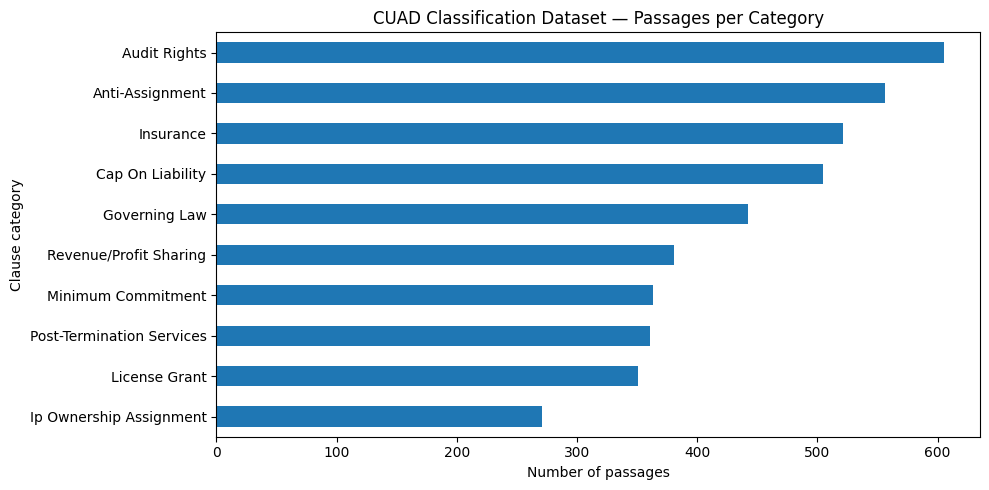

In [6]:
category_summary = (
    df.groupby(["label_id", "category"])
      .agg(
          passages=("example_id", "count"),
          contracts=("contract_id", "nunique"),
          median_words=("word_count", "median"),
          max_words=("word_count", "max"),
      )
      .reset_index()
      .sort_values("label_id")
)

display(category_summary)

fig, ax = plt.subplots(figsize=(10, 5))
category_counts = df["category"].value_counts().sort_values()
category_counts.plot(kind="barh", ax=ax)
ax.set_title("CUAD Classification Dataset — Passages per Category")
ax.set_xlabel("Number of passages")
ax.set_ylabel("Clause category")
plt.tight_layout()
plt.show()

## Phase 4 completion

The Google Colab environment, T4 GPU availability, repository data access, and contract-level split integrity were successfully validated. The following Phase 5 sections document the dataset source, adaptation method, structural audit, selected clause categories, representative records, length considerations, and split balance.

# Phase 5 — CUAD Source, Structure, and Data-Quality Audit

This section documents the provenance and structure of the Contract Understanding Atticus Dataset (CUAD), explains how the original clause-extraction annotations were adapted into a single-label classification dataset, and validates the processed records before model preprocessing begins.

The original CUAD v1 release contains 510 commercial contracts and more than 13,000 expert-supervised annotations across 41 clause categories. This project uses the official `master_clauses.csv` source and a reproducible preprocessing script stored in the repository. CUAD remains licensed separately from this project's code under the Creative Commons Attribution 4.0 International license.

**Official sources**

- Dataset overview: https://www.atticusprojectai.org/cuad/
- Archived release and DOI: https://doi.org/10.5281/zenodo.4595826
- Official repository: https://github.com/TheAtticusProject/cuad
- Dataset paper: *CUAD: An Expert-Annotated NLP Dataset for Legal Contract Review* (NeurIPS 2021)

The source benchmark was designed to locate legally significant passages within contracts. For this capstone, the expert-annotated answer passages are transparently adapted into a ten-class clause-theme classification task. The model therefore classifies passages that have already been identified as relevant; it does not perform complete autonomous contract review or provide legal advice.

## 7. Load the formal audit artifacts

The audit files were generated by the reproducible `src/prepare_cuad_classification.py` script and committed with the processed dataset. They record source dimensions, cleaning rules, category-selection logic, and split distributions.

In [7]:
import json
from urllib.request import urlopen

AUDIT_BASE_URL = (
    "https://raw.githubusercontent.com/"
    f"{REPOSITORY}/main/data/audit"
)

AUDIT_SUMMARY_URL = f"{AUDIT_BASE_URL}/cuad_data_audit_summary.json"
CATEGORY_AUDIT_URL = f"{AUDIT_BASE_URL}/cuad_selected_category_audit.csv"
SPLIT_DISTRIBUTION_URL = f"{AUDIT_BASE_URL}/cuad_split_distribution.csv"

with urlopen(AUDIT_SUMMARY_URL) as response:
    audit_summary = json.load(response)

category_audit = pd.read_csv(CATEGORY_AUDIT_URL)
split_distribution_audit = pd.read_csv(SPLIT_DISTRIBUTION_URL)

source_summary = pd.DataFrame(
    {
        "Measure": [
            "Source contracts",
            "Source columns",
            "Clause categories",
            "Raw annotated passages",
            "Clean unique passages across all 41 categories",
            "Final classification passages",
            "Final source contracts",
            "Final classes",
        ],
        "Value": [
            audit_summary["source"]["source_rows_contracts"],
            audit_summary["source"]["source_columns"],
            audit_summary["source"]["context_category_columns"],
            audit_summary["raw_audit"]["raw_context_annotations"],
            audit_summary["raw_audit"]["clean_unique_category_passages_all_41_categories"],
            audit_summary["final_dataset"]["examples"],
            audit_summary["final_dataset"]["distinct_contracts"],
            audit_summary["final_dataset"]["classes"],
        ],
    }
)

display(source_summary)
print(f"CUAD DOI: {audit_summary['source']['official_dataset_doi']}")
print(f"CUAD license: {audit_summary['source']['official_license']}")

,Measure,Value
0,Source contracts,510
1,Source columns,83
2,Clause categories,41
3,Raw annotated passages,13101
4,Clean unique passages across all 41 categories,9981
5,Final classification passages,4356
6,Final source contracts,462
7,Final classes,10


CUAD DOI: 10.5281/zenodo.4595826
CUAD license: CC BY 4.0


## 8. Adaptation and cleaning rules

The classification table was created using the following fixed rules:

1. Extract each expert-annotated clause passage and retain its source contract identifier and CUAD category.
2. Preserve the original passage for model input; normalize whitespace and letter case only for duplicate and conflict detection.
3. Within a category, retain one deterministic representative of identical normalized text.
4. Remove identical normalized passages assigned to more than one category because this capstone uses a single-label output.
5. Exclude blank or unparsable passages.
6. Exclude five metadata-oriented labels—Document Name, Parties, Agreement Date, Effective Date, and Expiration Date—from theme selection.
7. Require at least 100 distinct source contracts per eligible category.
8. Rank eligible categories by clean unique passage count and select the ten highest-volume categories, with alphabetical order as the tie-breaker.

These rules were fixed before model training and are not based on validation or test performance.

In [8]:
duplicate_audit = pd.DataFrame(
    {
        "Audit measure": [
            "Normalized text values appearing more than once",
            "Rows in any duplicate group",
            "Normalized text values assigned to multiple categories",
            "Rows in multiple-category conflict groups",
            "Clean unique passages remaining across all 41 categories",
        ],
        "Count": [
            audit_summary["raw_audit"]["normalized_text_values_with_any_duplicate"],
            audit_summary["raw_audit"]["rows_in_any_duplicate_group"],
            audit_summary["raw_audit"]["normalized_text_values_with_multiple_categories"],
            audit_summary["raw_audit"]["rows_in_multiple_category_groups"],
            audit_summary["raw_audit"]["clean_unique_category_passages_all_41_categories"],
        ],
    }
)

display(duplicate_audit)

integrity_audit = pd.DataFrame(
    {
        "Check": [
            "Missing values in required fields",
            "Duplicate example IDs",
            "Duplicate normalized-text hashes",
            "Contracts assigned to multiple splits",
            "Unexpected class count",
        ],
        "Result": [
            int(df[list(required_columns)].isna().sum().sum()),
            int(df["example_id"].duplicated().sum()),
            int(df["normalized_text_sha256"].duplicated().sum()),
            int((df.groupby("contract_id")["split"].nunique() > 1).sum()),
            int(df["category"].nunique() != 10),
        ],
    }
)

display(integrity_audit)

if integrity_audit["Result"].sum() != 0:
    raise ValueError("One or more processed-dataset integrity checks failed.")

print("All processed-dataset quality checks passed.")

,Audit measure,Count
0,Normalized text values appearing more than once,1336
1,Rows in any duplicate group,3393
2,Normalized text values assigned to multiple ca...,1063
3,Rows in multiple-category conflict groups,2344
4,Clean unique passages remaining across all 41 ...,9981


,Check,Result
0,Missing values in required fields,0
1,Duplicate example IDs,0
2,Duplicate normalized-text hashes,0
3,Contracts assigned to multiple splits,0
4,Unexpected class count,0


All processed-dataset quality checks passed.


## 9. Selected category audit

The ten selected categories represent substantive contract-review themes and are supported by at least 100 distinct contracts after cleaning. `retained_pct` shows the percentage of raw category annotations retained after duplicate and conflicting-label controls.

,label_id,category,raw_annotations,clean_unique_passages,clean_contracts,retained_pct,train,validation,test
0,0,Audit Rights,613,605,213,98.7%,485,61,59
1,1,Anti-Assignment,612,556,354,90.8%,445,55,56
2,2,Insurance,531,521,166,98.1%,417,52,52
3,3,Cap On Liability,632,505,227,79.9%,404,50,51
4,4,Governing Law,457,442,422,96.7%,353,45,44
5,5,Revenue/Profit Sharing,395,381,161,96.5%,305,38,38
6,6,Minimum Commitment,392,363,156,92.6%,291,36,36
7,7,Post-Termination Services,409,361,174,88.3%,288,36,37
8,8,License Grant,716,351,181,49.0%,281,35,35
9,9,Ip Ownership Assignment,296,271,114,91.6%,217,27,27


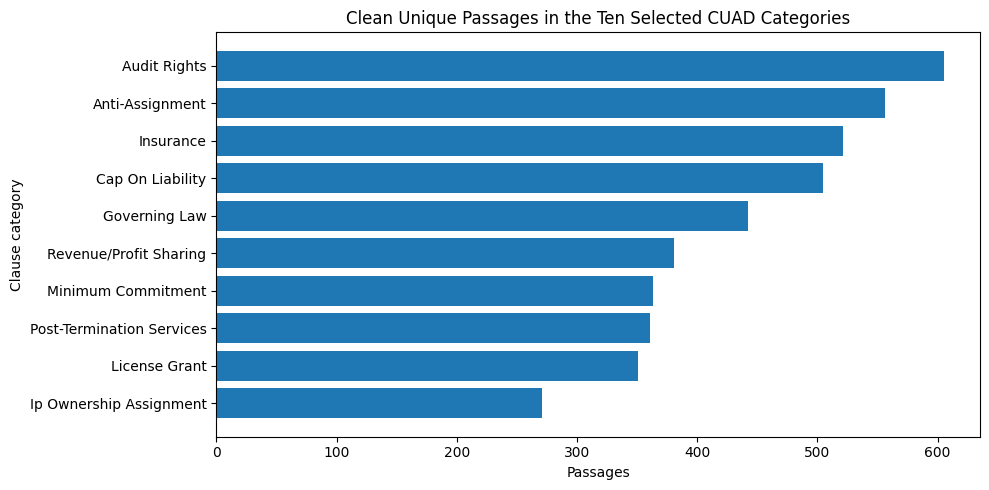

In [9]:
selected_category_table = (
    category_audit[
        [
            "label_id",
            "category",
            "raw_annotations",
            "clean_unique_passages",
            "clean_contracts",
            "retained_pct",
            "train",
            "validation",
            "test",
        ]
    ]
    .sort_values("label_id")
    .reset_index(drop=True)
)

display(
    selected_category_table.style.format(
        {
            "retained_pct": "{:.1f}%",
        }
    )
)

fig, ax = plt.subplots(figsize=(10, 5))
plot_data = selected_category_table.sort_values("clean_unique_passages")
ax.barh(plot_data["category"], plot_data["clean_unique_passages"])
ax.set_title("Clean Unique Passages in the Ten Selected CUAD Categories")
ax.set_xlabel("Passages")
ax.set_ylabel("Clause category")
plt.tight_layout()
plt.show()

## 10. Representative clause passages

A representative passage near the median word count is displayed for each category. These examples help verify that the inputs contain meaningful clause language rather than category names, filenames, or document metadata.

In [10]:
def select_near_median(group: pd.DataFrame) -> pd.Series:
    median_words = group["word_count"].median()
    selected_index = (group["word_count"] - median_words).abs().idxmin()
    return group.loc[selected_index]

representative_samples = (
    df.groupby(["label_id", "category"], group_keys=False)
      .apply(select_near_median, include_groups=False)
      .reset_index()
      .sort_values("label_id")
)

representative_samples["clause_excerpt"] = (
    representative_samples["clause_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.slice(0, 320)
)

display(
    representative_samples[
        ["label_id", "category", "split", "word_count", "clause_excerpt"]
    ].reset_index(drop=True)
)

,label_id,category,split,word_count,clause_excerpt
0,0,Audit Rights,validation,42,"Company shall have the right, under EUR OPS or..."
1,1,Anti-Assignment,train,36,This Agreement and all rights and duties hereu...
2,2,Insurance,validation,39,In respect of Hull and Spares All Risk Insuran...
3,3,Cap On Liability,train,48,Neither party shall be liable to the other par...
4,4,Governing Law,test,29,This Development Agreement shall be governed b...
5,5,Revenue/Profit Sharing,train,46,All payments shall be made by wire transfer dr...
6,6,Minimum Commitment,train,45,"With respect to each Contract Year, by no late..."
7,7,Post-Termination Services,train,60,"However, the Parties agree that the RemainCo G..."
8,8,License Grant,train,50,"Fox also grants Licensee a limited, non-exclus..."
9,9,Ip Ownership Assignment,train,54,Consultant also hereby irrevocably transfers a...


## 11. Clause-length and truncation considerations

The design uses a maximum sequence length of 256 model tokens. The source table currently records whitespace-delimited word counts, which serve only as a preliminary length proxy. Exact token lengths and actual truncation rates will be recalculated after the training-only vocabulary and tokenizer are built in Phase 7.

,quantile,word_count
0,0.00,2.00
1,0.25,28.00
2,0.50,43.00
3,0.75,67.00
4,0.90,100.00
5,0.95,136.00
6,0.99,238.45
7,1.00,704.00


Passages exceeding 256 whitespace-delimited words: 36 (0.83%)


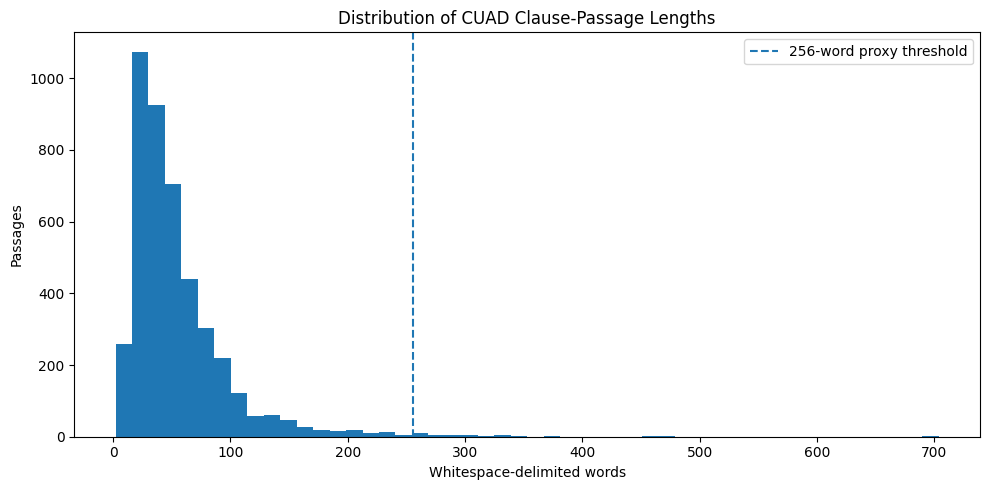

In [11]:
length_quantiles = (
    df["word_count"]
      .quantile([0.00, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00])
      .rename_axis("quantile")
      .reset_index(name="word_count")
)

display(length_quantiles)

word_proxy_over_limit = int((df["word_count"] > 256).sum())
word_proxy_over_limit_pct = 100 * word_proxy_over_limit / len(df)

print(
    f"Passages exceeding 256 whitespace-delimited words: "
    f"{word_proxy_over_limit:,} ({word_proxy_over_limit_pct:.2f}%)"
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["word_count"], bins=50)
ax.axvline(256, linestyle="--", label="256-word proxy threshold")
ax.set_title("Distribution of CUAD Clause-Passage Lengths")
ax.set_xlabel("Whitespace-delimited words")
ax.set_ylabel("Passages")
ax.legend()
plt.tight_layout()
plt.show()

## 12. Contract-grouped split balance

The processed dataset uses contract-level groups, so all passages from a source contract remain in one partition. This is more conservative than randomly splitting individual passages because similar language from the same contract cannot leak across training, validation, and test data.

split,train,validation,test
category,,,
Anti-Assignment,445,55,56
Audit Rights,485,61,59
Cap On Liability,404,50,51
Governing Law,353,45,44
Insurance,417,52,52
Ip Ownership Assignment,217,27,27
License Grant,281,35,35
Minimum Commitment,291,36,36
Post-Termination Services,288,36,37


split,train,validation,test
category,,,
Anti-Assignment,80.0%,9.9%,10.1%
Audit Rights,80.2%,10.1%,9.8%
Cap On Liability,80.0%,9.9%,10.1%
Governing Law,79.9%,10.2%,10.0%
Insurance,80.0%,10.0%,10.0%
Ip Ownership Assignment,80.1%,10.0%,10.0%
License Grant,80.1%,10.0%,10.0%
Minimum Commitment,80.2%,9.9%,9.9%
Post-Termination Services,79.8%,10.0%,10.2%


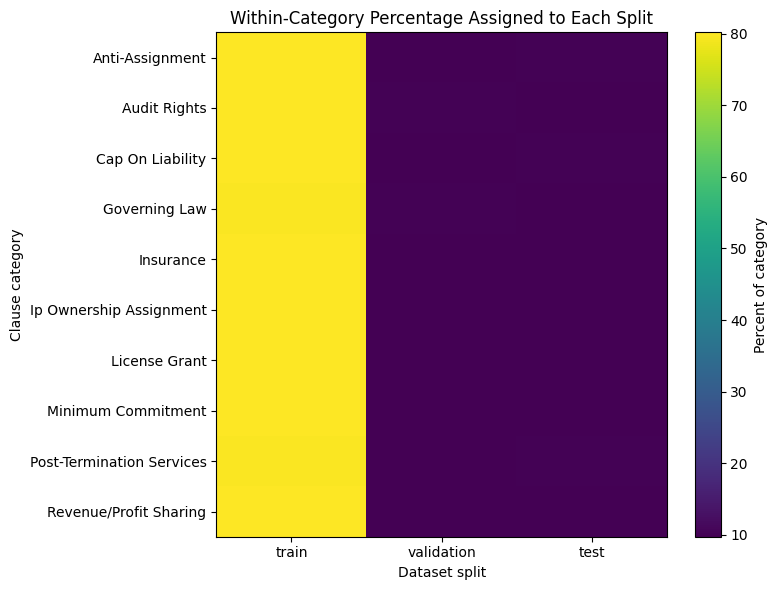

Unique contracts by split:


,contracts
split,
train,368
validation,48
test,46


In [12]:
split_order = ["train", "validation", "test"]
class_split_counts = pd.crosstab(df["category"], df["split"])[split_order]
class_split_pct = class_split_counts.div(class_split_counts.sum(axis=1), axis=0) * 100

display(class_split_counts)
display(class_split_pct.style.format("{:.1f}%"))

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(class_split_pct.values, aspect="auto")
ax.set_xticks(range(len(split_order)))
ax.set_xticklabels(split_order)
ax.set_yticks(range(len(class_split_pct.index)))
ax.set_yticklabels(class_split_pct.index)
ax.set_title("Within-Category Percentage Assigned to Each Split")
ax.set_xlabel("Dataset split")
ax.set_ylabel("Clause category")
fig.colorbar(image, ax=ax, label="Percent of category")
plt.tight_layout()
plt.show()

print("Unique contracts by split:")
display(
    df.groupby("split")["contract_id"]
      .nunique()
      .reindex(split_order)
      .rename("contracts")
      .to_frame()
)

## Phase 5 checkpoint

The CUAD structural audit is complete:

- The official source, DOI, license, and source-file structure are documented.
- The adaptation from clause extraction to single-label clause-theme classification is explicit.
- Cleaning, duplicate removal, conflicting-label removal, category selection, and contract-grouped splitting are reproducible.
- Required fields contain no missing values.
- Example IDs and normalized-text hashes are unique.
- No source contract occurs in more than one split.
- All ten selected categories appear in training, validation, and test data.
- Representative passages and length characteristics have been inspected.

The next phase constructs the training-only tokenizer and vocabulary, creates PyTorch Dataset and DataLoader objects, and implements the baseline Transformer architecture.

# Phase 7 — Text Pipeline and Baseline Transformer Implementation

This phase converts the audited clause passages into reproducible PyTorch inputs and implements the complete baseline neural architecture. To prevent information leakage, the vocabulary is built **only from training text**. Validation and test passages may contain out-of-vocabulary tokens, which are mapped to `<UNK>` rather than influencing feature construction.

The tokenizer lowercases each passage and separates alphabetic terms, numeric expressions, and punctuation. This preserves legally meaningful punctuation and numbers while keeping the implementation transparent and reproducible. The same vocabulary, encoded records, batch size, and DataLoader construction will be reused for both model configurations.

## 13. Load and validate the locked experiment configuration

The repository configuration records the architecture and training settings fixed before modeling. Loading it here reduces the risk that notebook code silently diverges from the documented experimental design.

In [13]:
from collections import Counter
from dataclasses import asdict, dataclass
import re

import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

CONFIG_URL = (
    "https://raw.githubusercontent.com/"
    f"{REPOSITORY}/main/config/experiment_configuration.json"
)

with urlopen(CONFIG_URL) as response:
    experiment_config = json.load(response)

MAX_SEQUENCE_LENGTH = experiment_config["dataset"]["max_sequence_length"]
VOCAB_MIN_FREQUENCY = experiment_config["dataset"]["vocabulary"]["min_frequency"]
VOCAB_MAX_SIZE = experiment_config["dataset"]["vocabulary"]["max_size"]
BATCH_SIZE = experiment_config["training_common"]["batch_size"]
NUM_CLASSES = experiment_config["final_dataset_classes"] if "final_dataset_classes" in experiment_config else len(
    experiment_config["dataset"]["selected_categories"]
)

locked_settings = pd.DataFrame(
    {
        "Setting": [
            "Maximum sequence length",
            "Minimum token frequency",
            "Maximum vocabulary size",
            "Batch size",
            "Embedding dimension",
            "Encoder layers",
            "Attention heads",
            "Feed-forward dimension",
            "Baseline dropout",
            "Experimental dropout",
        ],
        "Value": [
            MAX_SEQUENCE_LENGTH,
            VOCAB_MIN_FREQUENCY,
            VOCAB_MAX_SIZE,
            BATCH_SIZE,
            experiment_config["model"]["embedding_dim"],
            experiment_config["model"]["encoder_layers"],
            experiment_config["model"]["attention_heads"],
            experiment_config["model"]["feedforward_dim"],
            experiment_config["controlled_comparison"]["baseline"]["dropout"],
            experiment_config["controlled_comparison"]["experimental"]["dropout"],
        ],
    }
)

display(locked_settings)

assert NUM_CLASSES == 10
assert MAX_SEQUENCE_LENGTH == 256
assert BATCH_SIZE == 64
print("Locked experiment configuration loaded and validated.")

,Setting,Value
0,Maximum sequence length,256.0
1,Minimum token frequency,2.0
2,Maximum vocabulary size,20000.0
3,Batch size,64.0
4,Embedding dimension,128.0
5,Encoder layers,2.0
6,Attention heads,4.0
7,Feed-forward dimension,256.0
8,Baseline dropout,0.1
9,Experimental dropout,0.3


Locked experiment configuration loaded and validated.


## 14. Define the tokenizer and build the training-only vocabulary

Vocabulary ordering is deterministic: eligible tokens are sorted first by descending training frequency and then alphabetically. `<PAD>` has index 0 and `<UNK>` has index 1.

In [14]:
TOKEN_PATTERN = re.compile(
    r"[a-z]+(?:'[a-z]+)?|\d+(?:\.\d+)*|[^\w\s]"
)

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN]


def tokenize(text: str) -> list[str]:
    """Lowercase and separate words, numeric expressions, and punctuation."""
    if not isinstance(text, str):
        raise TypeError("Tokenizer input must be a string.")
    return TOKEN_PATTERN.findall(text.lower())


train_frame = df.loc[df["split"] == "train"].reset_index(drop=True)

token_counter = Counter()
for passage in train_frame["clause_text"]:
    token_counter.update(tokenize(passage))

eligible_tokens = [
    (token, frequency)
    for token, frequency in token_counter.items()
    if frequency >= VOCAB_MIN_FREQUENCY
]
eligible_tokens.sort(key=lambda item: (-item[1], item[0]))

available_slots = VOCAB_MAX_SIZE - len(SPECIAL_TOKENS)
index_to_token = SPECIAL_TOKENS + [
    token for token, _ in eligible_tokens[:available_slots]
]
token_to_index = {
    token: index for index, token in enumerate(index_to_token)
}

PAD_INDEX = token_to_index[PAD_TOKEN]
UNK_INDEX = token_to_index[UNK_TOKEN]
VOCAB_SIZE = len(index_to_token)

assert PAD_INDEX == 0
assert UNK_INDEX == 1
assert VOCAB_SIZE <= VOCAB_MAX_SIZE
assert all(
    token not in token_to_index
    for token in set(
        token
        for passage in df.loc[df["split"] != "train", "clause_text"]
        for token in tokenize(passage)
    ).difference(token_counter)
)

vocabulary_summary = pd.DataFrame(
    {
        "Measure": [
            "Unique tokens observed in training",
            "Tokens meeting minimum frequency",
            "Final vocabulary size including special tokens",
            "PAD index",
            "UNK index",
        ],
        "Value": [
            len(token_counter),
            len(eligible_tokens),
            VOCAB_SIZE,
            PAD_INDEX,
            UNK_INDEX,
        ],
    }
)

display(vocabulary_summary)

top_training_tokens = pd.DataFrame(
    token_counter.most_common(20),
    columns=["token", "training_frequency"],
)
display(top_training_tokens)

print("Vocabulary was constructed from training passages only.")

,Measure,Value
0,Unique tokens observed in training,6434
1,Tokens meeting minimum frequency,4415
2,Final vocabulary size including special tokens,4417
3,PAD index,0
4,UNK index,1


,token,training_frequency
0,the,12275
1,",",11961
2,of,8905
3,to,6926
4,and,6595
5,or,4971
6,-,4854
7,in,4166
8,.,4161
9,),3704


Vocabulary was constructed from training passages only.


## 15. Measure exact tokenizer lengths and out-of-vocabulary behavior

The earlier audit used whitespace-delimited words as a length proxy. This section calculates the exact lengths produced by the project tokenizer and measures the proportion of validation/test tokens mapped to `<UNK>`. These diagnostics are descriptive only and do not alter the locked maximum sequence length.

,passages,median_tokens,percentile_95_tokens,max_tokens,truncated_passages,unknown_tokens,total_tokens,truncated_pct,unknown_token_pct
split,,,,,,,,,
train,3486,50.0,164.0,1130,55,2019,226973,1.58%,0.89%
validation,435,53.0,184.0,601,12,1186,32306,2.76%,3.67%
test,435,51.0,169.2,476,8,1466,29812,1.84%,4.92%


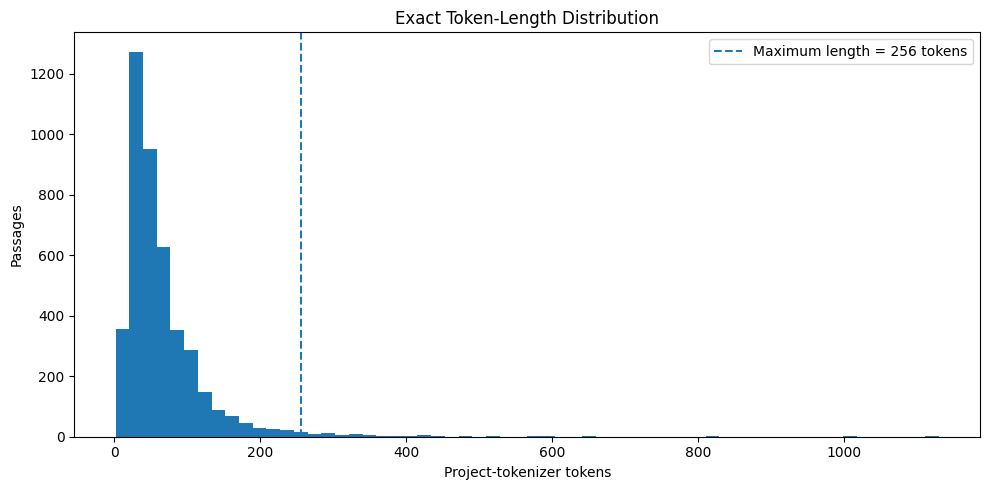

In [15]:
token_diagnostics = []

for row in df.itertuples(index=False):
    tokens = tokenize(row.clause_text)
    unknown_count = sum(
        token not in token_to_index for token in tokens
    )
    token_diagnostics.append(
        {
            "example_id": row.example_id,
            "split": row.split,
            "token_count": len(tokens),
            "unknown_token_count": unknown_count,
            "was_truncated": len(tokens) > MAX_SEQUENCE_LENGTH,
        }
    )

token_diagnostics = pd.DataFrame(token_diagnostics)
df = df.merge(
    token_diagnostics[
        [
            "example_id",
            "token_count",
            "unknown_token_count",
            "was_truncated",
        ]
    ],
    on="example_id",
    how="left",
    validate="one_to_one",
)

token_length_summary = (
    df.groupby("split")
      .agg(
          passages=("example_id", "count"),
          median_tokens=("token_count", "median"),
          percentile_95_tokens=("token_count", lambda values: values.quantile(0.95)),
          max_tokens=("token_count", "max"),
          truncated_passages=("was_truncated", "sum"),
          unknown_tokens=("unknown_token_count", "sum"),
          total_tokens=("token_count", "sum"),
      )
      .reindex(["train", "validation", "test"])
)

token_length_summary["truncated_pct"] = (
    100
    * token_length_summary["truncated_passages"]
    / token_length_summary["passages"]
)
token_length_summary["unknown_token_pct"] = (
    100
    * token_length_summary["unknown_tokens"]
    / token_length_summary["total_tokens"]
)

display(
    token_length_summary.style.format(
        {
            "median_tokens": "{:.1f}",
            "percentile_95_tokens": "{:.1f}",
            "truncated_pct": "{:.2f}%",
            "unknown_token_pct": "{:.2f}%",
        }
    )
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["token_count"], bins=60)
ax.axvline(
    MAX_SEQUENCE_LENGTH,
    linestyle="--",
    label=f"Maximum length = {MAX_SEQUENCE_LENGTH} tokens",
)
ax.set_title("Exact Token-Length Distribution")
ax.set_xlabel("Project-tokenizer tokens")
ax.set_ylabel("Passages")
ax.legend()
plt.tight_layout()
plt.show()

## 16. Create the PyTorch Dataset and deterministic DataLoaders

Each record is encoded to a fixed length of 256 tokens. Attention masks distinguish real tokens from padding. `num_workers=0` avoids multiprocessing differences in Colab, and the training loader receives a seeded generator. Calling `make_dataloaders()` again with the same seed reproduces the starting batch order for the controlled comparison.

In [16]:
class CUADClauseDataset(Dataset):
    """Encode CUAD clause passages for single-label classification."""

    def __init__(
        self,
        frame: pd.DataFrame,
        vocabulary: dict[str, int],
        max_length: int,
        pad_index: int,
        unknown_index: int,
    ) -> None:
        required = {"example_id", "clause_text", "label_id"}
        missing = required.difference(frame.columns)
        if missing:
            raise ValueError(
                f"Dataset frame is missing required columns: {sorted(missing)}"
            )

        self.records = frame[
            ["example_id", "clause_text", "label_id"]
        ].reset_index(drop=True)
        self.vocabulary = vocabulary
        self.max_length = max_length
        self.pad_index = pad_index
        self.unknown_index = unknown_index

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, index: int) -> dict[str, object]:
        row = self.records.iloc[index]
        tokens = tokenize(row["clause_text"])

        token_ids = [
            self.vocabulary.get(token, self.unknown_index)
            for token in tokens[: self.max_length]
        ]
        attention_mask = [1] * len(token_ids)

        padding_needed = self.max_length - len(token_ids)
        if padding_needed > 0:
            token_ids.extend([self.pad_index] * padding_needed)
            attention_mask.extend([0] * padding_needed)

        return {
            "input_ids": torch.tensor(token_ids, dtype=torch.long),
            "attention_mask": torch.tensor(
                attention_mask, dtype=torch.bool
            ),
            "label": torch.tensor(
                int(row["label_id"]), dtype=torch.long
            ),
            "example_id": str(row["example_id"]),
        }


def make_dataloaders(
    seed: int = SEED,
) -> tuple[dict[str, CUADClauseDataset], dict[str, DataLoader]]:
    """Create new loaders with a reproducible training shuffle."""

    datasets = {
        split: CUADClauseDataset(
            frame=df.loc[df["split"] == split],
            vocabulary=token_to_index,
            max_length=MAX_SEQUENCE_LENGTH,
            pad_index=PAD_INDEX,
            unknown_index=UNK_INDEX,
        )
        for split in ["train", "validation", "test"]
    }

    training_generator = torch.Generator()
    training_generator.manual_seed(seed)

    common_loader_settings = {
        "batch_size": BATCH_SIZE,
        "num_workers": 0,
        "pin_memory": torch.cuda.is_available(),
    }

    loaders = {
        "train": DataLoader(
            datasets["train"],
            shuffle=True,
            generator=training_generator,
            **common_loader_settings,
        ),
        "validation": DataLoader(
            datasets["validation"],
            shuffle=False,
            **common_loader_settings,
        ),
        "test": DataLoader(
            datasets["test"],
            shuffle=False,
            **common_loader_settings,
        ),
    }

    return datasets, loaders


clause_datasets, clause_loaders = make_dataloaders()

loader_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "dataset_records": [
            len(clause_datasets["train"]),
            len(clause_datasets["validation"]),
            len(clause_datasets["test"]),
        ],
        "batches": [
            len(clause_loaders["train"]),
            len(clause_loaders["validation"]),
            len(clause_loaders["test"]),
        ],
        "shuffle": [True, False, False],
    }
)

display(loader_summary)

,split,dataset_records,batches,shuffle
0,train,3486,55,True
1,validation,435,7,False
2,test,435,7,False


## 17. Validate one encoded batch

The model expects integer token IDs shaped `[batch, sequence]`, Boolean attention masks of the same shape, and one integer class label per passage.

In [17]:
sample_batch = next(iter(clause_loaders["train"]))

batch_validation = pd.DataFrame(
    {
        "Tensor": ["input_ids", "attention_mask", "label"],
        "Shape": [
            str(tuple(sample_batch["input_ids"].shape)),
            str(tuple(sample_batch["attention_mask"].shape)),
            str(tuple(sample_batch["label"].shape)),
        ],
        "Data type": [
            str(sample_batch["input_ids"].dtype),
            str(sample_batch["attention_mask"].dtype),
            str(sample_batch["label"].dtype),
        ],
    }
)

display(batch_validation)

assert sample_batch["input_ids"].shape == (
    BATCH_SIZE,
    MAX_SEQUENCE_LENGTH,
)
assert sample_batch["attention_mask"].shape == (
    BATCH_SIZE,
    MAX_SEQUENCE_LENGTH,
)
assert sample_batch["label"].shape == (BATCH_SIZE,)
assert sample_batch["input_ids"].dtype == torch.long
assert sample_batch["attention_mask"].dtype == torch.bool
assert sample_batch["label"].min().item() >= 0
assert sample_batch["label"].max().item() < NUM_CLASSES

print("Encoded batch shapes, data types, and label range are valid.")

,Tensor,Shape,Data type
0,input_ids,"(64, 256)",torch.int64
1,attention_mask,"(64, 256)",torch.bool
2,label,"(64,)",torch.int64


Encoded batch shapes, data types, and label range are valid.


## 18. Define the custom Transformer classifier

The classifier contains:

- A learned token embedding for each training-vocabulary entry
- A learned positional embedding for positions 0–255
- Two Transformer encoder layers
- Four self-attention heads per encoder layer
- A 256-unit feed-forward sublayer with GELU activation
- Padding-mask-aware mean pooling
- A dropout layer and a linear ten-class output layer

The padding mask is supplied both to self-attention and to mean pooling, so padded positions do not contribute to the passage representation.

In [18]:
@dataclass(frozen=True)
class TransformerModelConfig:
    vocab_size: int
    num_classes: int
    max_length: int
    embedding_dim: int
    num_heads: int
    num_layers: int
    feedforward_dim: int
    dropout: float
    pad_index: int


class TransformerClauseClassifier(nn.Module):
    """Transformer encoder for multiclass contract-clause classification."""

    def __init__(self, config: TransformerModelConfig) -> None:
        super().__init__()

        if config.embedding_dim % config.num_heads != 0:
            raise ValueError(
                "embedding_dim must be divisible by num_heads."
            )

        self.config = config
        self.token_embedding = nn.Embedding(
            num_embeddings=config.vocab_size,
            embedding_dim=config.embedding_dim,
            padding_idx=config.pad_index,
        )
        self.position_embedding = nn.Embedding(
            num_embeddings=config.max_length,
            embedding_dim=config.embedding_dim,
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config.embedding_dim,
            nhead=config.num_heads,
            dim_feedforward=config.feedforward_dim,
            dropout=config.dropout,
            activation="gelu",
            batch_first=True,
            norm_first=False,
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=config.num_layers,
            norm=nn.LayerNorm(config.embedding_dim),
        )
        self.output_dropout = nn.Dropout(config.dropout)
        self.classifier = nn.Linear(
            config.embedding_dim,
            config.num_classes,
        )

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
    ) -> torch.Tensor:
        batch_size, sequence_length = input_ids.shape

        if sequence_length > self.config.max_length:
            raise ValueError(
                f"Input length {sequence_length} exceeds configured "
                f"maximum {self.config.max_length}."
            )

        position_ids = (
            torch.arange(
                sequence_length,
                device=input_ids.device,
            )
            .unsqueeze(0)
            .expand(batch_size, -1)
        )

        hidden_states = (
            self.token_embedding(input_ids)
            + self.position_embedding(position_ids)
        )

        key_padding_mask = ~attention_mask.bool()
        encoded_states = self.encoder(
            hidden_states,
            src_key_padding_mask=key_padding_mask,
        )

        valid_token_mask = (
            attention_mask.unsqueeze(-1)
            .to(encoded_states.dtype)
        )
        pooled_states = (
            (encoded_states * valid_token_mask).sum(dim=1)
            / valid_token_mask.sum(dim=1).clamp(min=1.0)
        )

        logits = self.classifier(
            self.output_dropout(pooled_states)
        )
        return logits


def build_model(dropout: float) -> TransformerClauseClassifier:
    """Initialize a model reproducibly for one experiment configuration."""

    set_seed(SEED)

    model_config = TransformerModelConfig(
        vocab_size=VOCAB_SIZE,
        num_classes=NUM_CLASSES,
        max_length=MAX_SEQUENCE_LENGTH,
        embedding_dim=experiment_config["model"]["embedding_dim"],
        num_heads=experiment_config["model"]["attention_heads"],
        num_layers=experiment_config["model"]["encoder_layers"],
        feedforward_dim=experiment_config["model"]["feedforward_dim"],
        dropout=dropout,
        pad_index=PAD_INDEX,
    )
    return TransformerClauseClassifier(model_config)


baseline_dropout = experiment_config[
    "controlled_comparison"
]["baseline"]["dropout"]

baseline_model = build_model(
    dropout=baseline_dropout
).to(DEVICE)

print(baseline_model)
print("\nBaseline model configuration:")
display(
    pd.DataFrame(
        asdict(baseline_model.config).items(),
        columns=["Setting", "Value"],
    )
)

TransformerClauseClassifier(
  (token_embedding): Embedding(4417, 128, padding_idx=0)
  (position_embedding): Embedding(256, 128)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (output_dropout): Dropout(p=0.1, inplace=False)
  (classifier): Linear(in_features=128, out_featu

,Setting,Value
0,vocab_size,4417.0
1,num_classes,10.0
2,max_length,256.0
3,embedding_dim,128.0
4,num_heads,4.0
5,num_layers,2.0
6,feedforward_dim,256.0
7,dropout,0.1
8,pad_index,0.0


## 19. Count trainable parameters and validate the forward pass

The forward-pass check confirms that one batch produces a finite logit for each of the ten target classes. The model remains untrained at this point.

In [19]:
def count_parameters(model: nn.Module) -> tuple[int, int]:
    total = sum(parameter.numel() for parameter in model.parameters())
    trainable = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )
    return total, trainable


total_parameters, trainable_parameters = count_parameters(
    baseline_model
)

input_ids = sample_batch["input_ids"].to(
    DEVICE, non_blocking=True
)
attention_mask = sample_batch["attention_mask"].to(
    DEVICE, non_blocking=True
)

baseline_model.eval()
with torch.no_grad():
    sample_logits = baseline_model(
        input_ids=input_ids,
        attention_mask=attention_mask,
    )

assert sample_logits.shape == (BATCH_SIZE, NUM_CLASSES)
assert torch.isfinite(sample_logits).all()

parameter_summary = pd.DataFrame(
    {
        "Measure": [
            "Total parameters",
            "Trainable parameters",
            "Vocabulary size",
            "Output classes",
            "Forward-pass output shape",
        ],
        "Value": [
            f"{total_parameters:,}",
            f"{trainable_parameters:,}",
            f"{VOCAB_SIZE:,}",
            NUM_CLASSES,
            str(tuple(sample_logits.shape)),
        ],
    }
)

display(parameter_summary)
print("Forward pass completed with finite ten-class logits.")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


,Measure,Value
0,Total parameters,"864,650"
1,Trainable parameters,"864,650"
2,Vocabulary size,"4,417"
3,Output classes,10
4,Forward-pass output shape,"(64, 10)"


Forward pass completed with finite ten-class logits.


## 20. Run a one-batch optimization sanity check

A temporary model performs exactly one optimization step to verify loss computation, backpropagation, gradient clipping, and AdamW updates. This temporary model is discarded afterward; the actual baseline training run will start from a fresh seed-controlled initialization.

In [20]:
pilot_model = build_model(
    dropout=baseline_dropout
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
pilot_optimizer = torch.optim.AdamW(
    pilot_model.parameters(),
    lr=experiment_config["training_common"]["learning_rate"],
    weight_decay=experiment_config[
        "training_common"
    ]["weight_decay"],
)

pilot_model.train()
pilot_optimizer.zero_grad(set_to_none=True)

pilot_logits = pilot_model(
    input_ids=input_ids,
    attention_mask=attention_mask,
)
pilot_labels = sample_batch["label"].to(
    DEVICE, non_blocking=True
)
pilot_loss = criterion(pilot_logits, pilot_labels)

if not torch.isfinite(pilot_loss):
    raise RuntimeError("Pilot loss is not finite.")

pilot_loss.backward()
gradient_norm = nn.utils.clip_grad_norm_(
    pilot_model.parameters(),
    max_norm=experiment_config[
        "training_common"
    ]["gradient_clip_norm"],
)
pilot_optimizer.step()

pilot_results = pd.DataFrame(
    {
        "Check": [
            "Finite cross-entropy loss",
            "Loss value before update",
            "Gradient norm before clipping",
            "Configured clipping threshold",
            "Optimizer step completed",
        ],
        "Result": [
            bool(torch.isfinite(pilot_loss).item()),
            f"{pilot_loss.detach().item():.6f}",
            f"{gradient_norm.detach().item():.6f}",
            experiment_config[
                "training_common"
            ]["gradient_clip_norm"],
            True,
        ],
    }
)

display(pilot_results)

del pilot_model, pilot_optimizer, pilot_logits, pilot_loss
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Recreate the untouched baseline model for the future training phase.
baseline_model = build_model(
    dropout=baseline_dropout
).to(DEVICE)

print(
    "One-batch optimization sanity check passed. "
    "A fresh untrained baseline model has been restored."
)

,Check,Result
0,Finite cross-entropy loss,True
1,Loss value before update,2.310871
2,Gradient norm before clipping,0.667233
3,Configured clipping threshold,1.0
4,Optimizer step completed,True


One-batch optimization sanity check passed. A fresh untrained baseline model has been restored.


## Phase 7 checkpoint

The text and model pipeline is ready for pilot training:

- The locked experiment configuration loads from the repository.
- The regex tokenizer is defined transparently.
- The vocabulary is constructed exclusively from training passages.
- Exact token lengths, truncation rates, and out-of-vocabulary rates are measured.
- Training, validation, and test datasets use the same fixed encoding rules.
- The training DataLoader uses a seeded shuffle that can be recreated for both configurations.
- Tensor shapes, data types, and label ranges pass validation.
- The custom two-layer Transformer produces finite ten-class logits.
- Cross-entropy loss, backpropagation, gradient clipping, and AdamW optimization execute successfully.
- The temporary optimization model is discarded, and the baseline is reset to a fresh reproducible initialization.

The next phase implements reusable training and validation functions, performs a short pilot run, and verifies learning behavior, runtime, checkpoint selection, and GPU-memory suitability before the 15-epoch controlled experiment begins.

# Phase 8 — Reusable Training Functions and Baseline Pilot

Before committing GPU time to both 15-epoch configurations, this phase performs a short three-epoch pilot using the baseline dropout of 0.10. The pilot verifies that:

- The training and validation loops execute correctly.
- Cross-entropy loss remains finite and decreases.
- Validation metrics can be calculated consistently.
- The documented checkpoint-selection rule works.
- T4 epoch time and peak memory are suitable for the full experiment.

The pilot uses the training and validation partitions only. The untouched test partition is **not evaluated**. Pilot weights and results are diagnostic and will not be used as either final model configuration.

## 21. Define metric, training, validation, and checkpoint functions

The same functions will be used for the baseline and experimental configurations. Epoch losses are averaged by record rather than by batch, so the smaller final batch receives the correct weight. The best checkpoint is selected by highest validation macro F1, with lower validation loss used as the tie-breaker.

In [21]:
import copy
import time

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)


def calculate_classification_metrics(
    labels: list[int],
    predictions: list[int],
) -> dict[str, float]:
    """Return task-level metrics using fixed ten-class label support."""

    label_space = list(range(NUM_CLASSES))
    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            labels=label_space,
            average="macro",
            zero_division=0,
        )
    )
    weighted_f1 = f1_score(
        labels,
        predictions,
        labels=label_space,
        average="weighted",
        zero_division=0,
    )

    return {
        "accuracy": accuracy_score(labels, predictions),
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }


def run_training_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
) -> dict[str, float]:
    """Train for one epoch and return record-weighted metrics."""

    model.train()

    total_loss = 0.0
    total_records = 0
    labels_all: list[int] = []
    predictions_all: list[int] = []

    for batch in loader:
        input_ids = batch["input_ids"].to(
            DEVICE, non_blocking=True
        )
        attention_mask = batch["attention_mask"].to(
            DEVICE, non_blocking=True
        )
        labels = batch["label"].to(
            DEVICE, non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        loss = criterion(logits, labels)

        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite training loss detected.")

        loss.backward()
        nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=experiment_config[
                "training_common"
            ]["gradient_clip_norm"],
        )
        optimizer.step()

        batch_size_actual = labels.size(0)
        total_loss += loss.detach().item() * batch_size_actual
        total_records += batch_size_actual

        predictions = logits.argmax(dim=1)
        labels_all.extend(labels.detach().cpu().tolist())
        predictions_all.extend(
            predictions.detach().cpu().tolist()
        )

    metrics = calculate_classification_metrics(
        labels=labels_all,
        predictions=predictions_all,
    )
    metrics["loss"] = total_loss / total_records
    return metrics


@torch.no_grad()
def evaluate_model(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    collect_details: bool = False,
) -> dict[str, object]:
    """Evaluate a model without modifying parameters or gradients."""

    model.eval()

    total_loss = 0.0
    total_records = 0
    labels_all: list[int] = []
    predictions_all: list[int] = []
    probabilities_all: list[list[float]] = []
    example_ids_all: list[str] = []

    for batch in loader:
        input_ids = batch["input_ids"].to(
            DEVICE, non_blocking=True
        )
        attention_mask = batch["attention_mask"].to(
            DEVICE, non_blocking=True
        )
        labels = batch["label"].to(
            DEVICE, non_blocking=True
        )

        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        loss = criterion(logits, labels)

        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite evaluation loss detected.")

        probabilities = torch.softmax(logits, dim=1)
        predictions = probabilities.argmax(dim=1)

        batch_size_actual = labels.size(0)
        total_loss += loss.detach().item() * batch_size_actual
        total_records += batch_size_actual

        labels_all.extend(labels.detach().cpu().tolist())
        predictions_all.extend(
            predictions.detach().cpu().tolist()
        )

        if collect_details:
            probabilities_all.extend(
                probabilities.detach().cpu().tolist()
            )
            example_ids_all.extend(batch["example_id"])

    metrics: dict[str, object] = calculate_classification_metrics(
        labels=labels_all,
        predictions=predictions_all,
    )
    metrics["loss"] = total_loss / total_records

    if collect_details:
        metrics["labels"] = labels_all
        metrics["predictions"] = predictions_all
        metrics["probabilities"] = probabilities_all
        metrics["example_ids"] = example_ids_all

    return metrics


def checkpoint_is_better(
    candidate_macro_f1: float,
    candidate_loss: float,
    best_macro_f1: float,
    best_loss: float,
    tolerance: float = 1e-12,
) -> bool:
    """Apply the locked macro-F1 then validation-loss checkpoint rule."""

    if candidate_macro_f1 > best_macro_f1 + tolerance:
        return True

    f1_tied = abs(candidate_macro_f1 - best_macro_f1) <= tolerance
    return f1_tied and candidate_loss < best_loss


def fit_model(
    model: nn.Module,
    loaders: dict[str, DataLoader],
    epochs: int,
    run_name: str,
) -> tuple[nn.Module, pd.DataFrame, dict[str, object]]:
    """Train, validate, select, and restore the best checkpoint."""

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=experiment_config[
            "training_common"
        ]["learning_rate"],
        weight_decay=experiment_config[
            "training_common"
        ]["weight_decay"],
    )

    best_macro_f1 = float("-inf")
    best_validation_loss = float("inf")
    best_epoch = 0
    best_state: dict[str, torch.Tensor] | None = None
    history_records: list[dict[str, float | int]] = []

    run_start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        epoch_start = time.perf_counter()

        training_metrics = run_training_epoch(
            model=model,
            loader=loaders["train"],
            optimizer=optimizer,
            criterion=criterion,
        )
        validation_metrics = evaluate_model(
            model=model,
            loader=loaders["validation"],
            criterion=criterion,
        )

        epoch_seconds = time.perf_counter() - epoch_start

        history_record = {
            "epoch": epoch,
            "train_loss": training_metrics["loss"],
            "train_accuracy": training_metrics["accuracy"],
            "train_macro_f1": training_metrics["macro_f1"],
            "validation_loss": validation_metrics["loss"],
            "validation_accuracy": validation_metrics["accuracy"],
            "validation_macro_f1": validation_metrics["macro_f1"],
            "epoch_seconds": epoch_seconds,
        }
        history_records.append(history_record)

        if checkpoint_is_better(
            candidate_macro_f1=validation_metrics["macro_f1"],
            candidate_loss=validation_metrics["loss"],
            best_macro_f1=best_macro_f1,
            best_loss=best_validation_loss,
        ):
            best_macro_f1 = validation_metrics["macro_f1"]
            best_validation_loss = validation_metrics["loss"]
            best_epoch = epoch
            best_state = {
                name: tensor.detach().cpu().clone()
                for name, tensor in model.state_dict().items()
            }

        print(
            f"{run_name} | Epoch {epoch:02d}/{epochs:02d} | "
            f"train loss {training_metrics['loss']:.4f} | "
            f"val loss {validation_metrics['loss']:.4f} | "
            f"val accuracy {validation_metrics['accuracy']:.4f} | "
            f"val macro F1 {validation_metrics['macro_f1']:.4f} | "
            f"{epoch_seconds:.1f}s"
        )

    if best_state is None:
        raise RuntimeError("No valid checkpoint was created.")

    model.load_state_dict(best_state)
    model.to(DEVICE)

    total_seconds = time.perf_counter() - run_start
    history = pd.DataFrame(history_records)

    run_summary: dict[str, object] = {
        "run_name": run_name,
        "epochs": epochs,
        "best_epoch": best_epoch,
        "best_validation_macro_f1": best_macro_f1,
        "best_validation_loss": best_validation_loss,
        "total_seconds": total_seconds,
        "mean_epoch_seconds": history["epoch_seconds"].mean(),
    }

    return model, history, run_summary


print("Reusable training, validation, and checkpoint functions are ready.")

Reusable training, validation, and checkpoint functions are ready.


## 22. Run a three-epoch baseline pilot

The pilot begins with a fresh model and a newly seeded training DataLoader. CUDA peak-memory statistics are reset immediately before training. The result is used only to assess feasibility and mechanics.

In [22]:
PILOT_EPOCHS = 3

# Remove the Phase 7 model before measuring pilot memory.
del baseline_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

pilot_datasets, pilot_loaders = make_dataloaders(
    seed=SEED
)
pilot_model = build_model(
    dropout=baseline_dropout
).to(DEVICE)

pilot_model, pilot_history, pilot_run_summary = fit_model(
    model=pilot_model,
    loaders=pilot_loaders,
    epochs=PILOT_EPOCHS,
    run_name="Baseline pilot",
)

if torch.cuda.is_available():
    pilot_peak_memory_gb = (
        torch.cuda.max_memory_allocated() / (1024 ** 3)
    )
else:
    pilot_peak_memory_gb = float("nan")

pilot_run_summary["peak_gpu_memory_gb"] = pilot_peak_memory_gb
pilot_run_summary["estimated_two_model_15_epoch_minutes"] = (
    pilot_run_summary["mean_epoch_seconds"] * 30 / 60
)

display(
    pd.DataFrame(
        pilot_run_summary.items(),
        columns=["Pilot measure", "Value"],
    )
)

display(
    pilot_history.style.format(
        {
            "train_loss": "{:.4f}",
            "train_accuracy": "{:.4f}",
            "train_macro_f1": "{:.4f}",
            "validation_loss": "{:.4f}",
            "validation_accuracy": "{:.4f}",
            "validation_macro_f1": "{:.4f}",
            "epoch_seconds": "{:.1f}",
        }
    )
)

Baseline pilot | Epoch 01/03 | train loss 1.8631 | val loss 1.2524 | val accuracy 0.5816 | val macro F1 0.4987 | 2.4s
Baseline pilot | Epoch 02/03 | train loss 1.0029 | val loss 0.7884 | val accuracy 0.7540 | val macro F1 0.7231 | 2.3s
Baseline pilot | Epoch 03/03 | train loss 0.6103 | val loss 0.5482 | val accuracy 0.8253 | val macro F1 0.8028 | 2.5s


,Pilot measure,Value
0,run_name,Baseline pilot
1,epochs,3
2,best_epoch,3
3,best_validation_macro_f1,0.802767
4,best_validation_loss,0.548212
5,total_seconds,7.254371
6,mean_epoch_seconds,2.412659
7,peak_gpu_memory_gb,0.28428
8,estimated_two_model_15_epoch_minutes,1.206329


,epoch,train_loss,train_accuracy,train_macro_f1,validation_loss,validation_accuracy,validation_macro_f1,epoch_seconds
0,1,1.8631,0.3893,0.3189,1.2524,0.5816,0.4987,2.4
1,2,1.0029,0.6830,0.6276,0.7884,0.7540,0.7231,2.3
2,3,0.6103,0.7975,0.7654,0.5482,0.8253,0.8028,2.5


## 23. Visualize pilot learning behavior

The pilot plots are diagnostic rather than final project results. The formal report will use the complete 15-epoch histories for both controlled configurations.

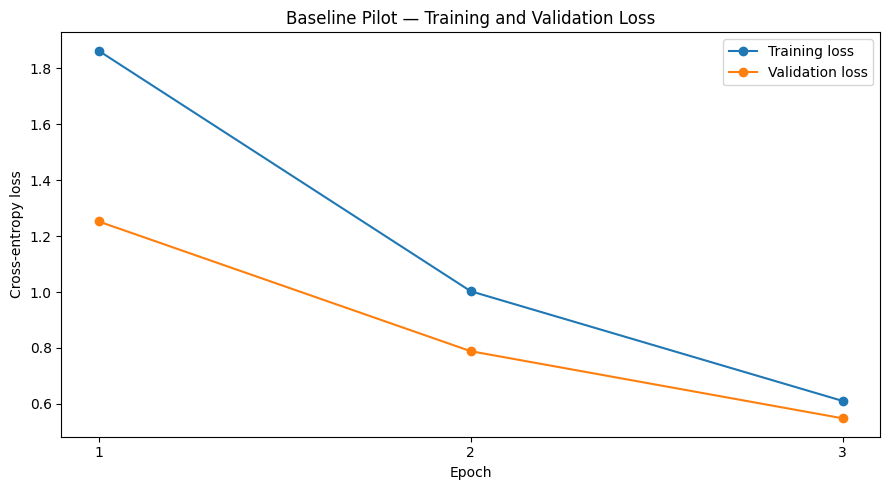

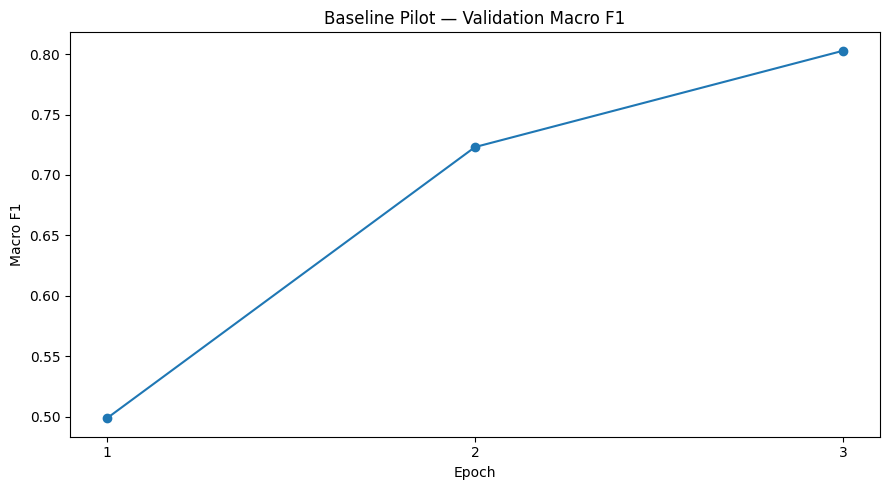

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    pilot_history["epoch"],
    pilot_history["train_loss"],
    marker="o",
    label="Training loss",
)
ax.plot(
    pilot_history["epoch"],
    pilot_history["validation_loss"],
    marker="o",
    label="Validation loss",
)
ax.set_title("Baseline Pilot — Training and Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_xticks(pilot_history["epoch"])
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    pilot_history["epoch"],
    pilot_history["validation_macro_f1"],
    marker="o",
)
ax.set_title("Baseline Pilot — Validation Macro F1")
ax.set_xlabel("Epoch")
ax.set_ylabel("Macro F1")
ax.set_xticks(pilot_history["epoch"])
plt.tight_layout()
plt.show()

## 24. Evaluate pilot readiness against transparent gates

A majority-class prediction provides a minimal validation reference. Pilot readiness is based on finite outputs, decreasing training loss, successful checkpoint restoration, performance above the majority-class macro-F1 reference, and practical GPU memory consumption. These gates validate the workflow; they do not establish final model quality.

In [24]:
validation_frame = df.loc[
    df["split"] == "validation"
].reset_index(drop=True)

training_majority_label = int(
    df.loc[df["split"] == "train", "label_id"]
      .mode()
      .iloc[0]
)
majority_predictions = [
    training_majority_label
] * len(validation_frame)

majority_metrics = calculate_classification_metrics(
    labels=validation_frame["label_id"].astype(int).tolist(),
    predictions=majority_predictions,
)

best_pilot_validation = evaluate_model(
    model=pilot_model,
    loader=pilot_loaders["validation"],
    criterion=nn.CrossEntropyLoss(),
)

finite_history = bool(
    np.isfinite(
        pilot_history.select_dtypes(include=[np.number]).to_numpy()
    ).all()
)
training_loss_decreased = bool(
    pilot_history["train_loss"].iloc[-1]
    < pilot_history["train_loss"].iloc[0]
)
above_majority_macro_f1 = bool(
    best_pilot_validation["macro_f1"]
    > majority_metrics["macro_f1"]
)
checkpoint_restored = bool(
    abs(
        best_pilot_validation["macro_f1"]
        - pilot_run_summary["best_validation_macro_f1"]
    )
    <= 1e-10
)
memory_suitable = bool(
    np.isnan(pilot_peak_memory_gb)
    or pilot_peak_memory_gb < 12.0
)

pilot_gate_table = pd.DataFrame(
    {
        "Readiness gate": [
            "All pilot history values are finite",
            "Training loss decreased across the pilot",
            "Best checkpoint restored correctly",
            "Pilot macro F1 exceeds majority reference",
            "Peak GPU memory is below 12 GB",
        ],
        "Passed": [
            finite_history,
            training_loss_decreased,
            checkpoint_restored,
            above_majority_macro_f1,
            memory_suitable,
        ],
        "Evidence": [
            "No NaN or infinite numeric results",
            (
                f"{pilot_history['train_loss'].iloc[0]:.4f} "
                f"to {pilot_history['train_loss'].iloc[-1]:.4f}"
            ),
            (
                f"restored F1 {best_pilot_validation['macro_f1']:.4f}; "
                f"recorded best {pilot_run_summary['best_validation_macro_f1']:.4f}"
            ),
            (
                f"pilot {best_pilot_validation['macro_f1']:.4f}; "
                f"majority {majority_metrics['macro_f1']:.4f}"
            ),
            (
                f"{pilot_peak_memory_gb:.3f} GB"
                if not np.isnan(pilot_peak_memory_gb)
                else "CPU runtime"
            ),
        ],
    }
)

display(pilot_gate_table)

pilot_ready = bool(pilot_gate_table["Passed"].all())
print(
    "Pilot readiness decision:",
    "READY FOR FULL TRAINING" if pilot_ready
    else "REVIEW REQUIRED BEFORE FULL TRAINING",
)

,Readiness gate,Passed,Evidence
0,All pilot history values are finite,True,No NaN or infinite numeric results
1,Training loss decreased across the pilot,True,1.8631 to 0.6103
2,Best checkpoint restored correctly,True,restored F1 0.8028; recorded best 0.8028
3,Pilot macro F1 exceeds majority reference,True,pilot 0.8028; majority 0.0246
4,Peak GPU memory is below 12 GB,True,0.284 GB


Pilot readiness decision: READY FOR FULL TRAINING


## 25. Discard pilot weights and restore the formal baseline starting state

The pilot does not count as the baseline experiment. Its model and loaders are deleted, GPU cache is cleared, and a fresh untrained baseline model is recreated using the locked seed and dropout. Full training will also recreate the DataLoaders from the same seed.

In [25]:
del pilot_model, pilot_datasets, pilot_loaders
if torch.cuda.is_available():
    torch.cuda.empty_cache()

baseline_model = build_model(
    dropout=baseline_dropout
).to(DEVICE)
clause_datasets, clause_loaders = make_dataloaders(
    seed=SEED
)

restored_total_parameters, restored_trainable_parameters = (
    count_parameters(baseline_model)
)

assert restored_total_parameters == total_parameters
assert restored_trainable_parameters == trainable_parameters

print(
    "Pilot model discarded. Fresh untrained baseline model and "
    "seeded DataLoaders restored for formal training."
)

Pilot model discarded. Fresh untrained baseline model and seeded DataLoaders restored for formal training.


## Phase 8 checkpoint

The pilot-training phase is complete when all readiness gates pass:

- Reusable training and validation loops execute on the T4 GPU.
- Losses and metrics remain finite.
- Training loss decreases during the three-epoch pilot.
- Validation macro F1 exceeds the majority-class reference.
- The checkpoint selected by validation macro F1 is restored correctly.
- Peak memory is comfortably below T4 capacity.
- Epoch timing supports two complete 15-epoch configurations.
- The test partition remains untouched.
- Pilot weights are discarded, and the baseline is reset to the formal seed-controlled starting state.

The next phase trains the baseline model for all 15 epochs, restores its best validation checkpoint, and preserves its complete training history. The experimental model will then be trained from an equivalent initialization and DataLoader seed with dropout as the only major change.

# Phase 9 — Full Controlled Training Experiment

This phase trains both locked configurations for all 15 epochs:

- **Baseline:** dropout = 0.10
- **Experimental:** dropout = 0.30

Dropout probability is the only major difference. Both runs use the same records, vocabulary, encoded sequences, Transformer dimensions, seed, initial parameter values, batch order, optimizer, learning rate, epoch count, metrics, and checkpoint rule. The test partition remains untouched until both best validation checkpoints are frozen.

## 26. Verify controlled-comparison equivalence

Temporary models and DataLoaders verify identical initial tensors and identical first-batch order. They are discarded before formal training.

In [26]:
experimental_dropout = experiment_config["controlled_comparison"]["experimental"]["dropout"]

baseline_audit_model = build_model(dropout=baseline_dropout)
experimental_audit_model = build_model(dropout=experimental_dropout)

baseline_state = baseline_audit_model.state_dict()
experimental_state = experimental_audit_model.state_dict()

_, baseline_audit_loaders = make_dataloaders(seed=SEED)
_, experimental_audit_loaders = make_dataloaders(seed=SEED)
baseline_first_batch = next(iter(baseline_audit_loaders["train"]))
experimental_first_batch = next(iter(experimental_audit_loaders["train"]))

controlled_comparison_audit = pd.DataFrame(
    {
        "Control check": [
            "Parameter names match",
            "Parameter shapes match",
            "Initial parameter values match",
            "First shuffled batch IDs match",
            "First shuffled batch inputs match",
            "First shuffled batch labels match",
            "Only dropout differs",
        ],
        "Passed": [
            list(baseline_state) == list(experimental_state),
            all(baseline_state[n].shape == experimental_state[n].shape for n in baseline_state),
            all(torch.equal(baseline_state[n], experimental_state[n]) for n in baseline_state),
            baseline_first_batch["example_id"] == experimental_first_batch["example_id"],
            torch.equal(baseline_first_batch["input_ids"], experimental_first_batch["input_ids"]),
            torch.equal(baseline_first_batch["label"], experimental_first_batch["label"]),
            baseline_dropout != experimental_dropout,
        ],
        "Evidence": [
            f"{len(baseline_state)} tensors",
            "All tensor shapes equal",
            "All initial tensors equal",
            f"{len(baseline_first_batch['example_id'])} IDs",
            str(tuple(baseline_first_batch["input_ids"].shape)),
            str(tuple(baseline_first_batch["label"].shape)),
            f"{baseline_dropout:.2f} versus {experimental_dropout:.2f}",
        ],
    }
)

display(controlled_comparison_audit)
if not bool(controlled_comparison_audit["Passed"].all()):
    raise RuntimeError("Controlled-comparison equivalence audit failed.")

del baseline_audit_model, experimental_audit_model
del baseline_audit_loaders, experimental_audit_loaders
del baseline_first_batch, experimental_first_batch
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Controlled-comparison audit passed: dropout is the only major difference.")

,Control check,Passed,Evidence
0,Parameter names match,True,30 tensors
1,Parameter shapes match,True,All tensor shapes equal
2,Initial parameter values match,True,All initial tensors equal
3,First shuffled batch IDs match,True,64 IDs
4,First shuffled batch inputs match,True,"(64, 256)"
5,First shuffled batch labels match,True,"(64,)"
6,Only dropout differs,True,0.10 versus 0.30


Controlled-comparison audit passed: dropout is the only major difference.


## 27. Train and freeze the 15-epoch baseline

The formal baseline begins from a fresh seed-controlled model and DataLoader. All 15 epochs run, after which the best validation checkpoint is restored and copied to CPU memory.

In [27]:
FORMAL_EPOCHS = experiment_config["training_common"]["epochs"]
if FORMAL_EPOCHS != 15:
    raise ValueError(f"Expected 15 formal epochs, found {FORMAL_EPOCHS}.")

del baseline_model, clause_datasets, clause_loaders
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

baseline_datasets, baseline_loaders = make_dataloaders(seed=SEED)
baseline_model = build_model(dropout=baseline_dropout).to(DEVICE)

baseline_model, baseline_history, baseline_run_summary = fit_model(
    model=baseline_model,
    loaders=baseline_loaders,
    epochs=FORMAL_EPOCHS,
    run_name="Formal baseline",
)

baseline_peak_memory_gb = (
    torch.cuda.max_memory_allocated() / (1024 ** 3)
    if torch.cuda.is_available() else float("nan")
)
baseline_run_summary["dropout"] = baseline_dropout
baseline_run_summary["peak_gpu_memory_gb"] = baseline_peak_memory_gb

baseline_best_validation = evaluate_model(
    model=baseline_model,
    loader=baseline_loaders["validation"],
    criterion=nn.CrossEntropyLoss(),
)
baseline_checkpoint_matches = abs(
    baseline_best_validation["macro_f1"]
    - baseline_run_summary["best_validation_macro_f1"]
) <= 1e-10
if not baseline_checkpoint_matches:
    raise RuntimeError("Baseline checkpoint verification failed.")

baseline_best_state = {
    name: tensor.detach().cpu().clone()
    for name, tensor in baseline_model.state_dict().items()
}

display(pd.DataFrame(baseline_run_summary.items(), columns=["Baseline measure", "Value"]))
display(baseline_history.style.format({
    "train_loss": "{:.4f}",
    "train_accuracy": "{:.4f}",
    "train_macro_f1": "{:.4f}",
    "validation_loss": "{:.4f}",
    "validation_accuracy": "{:.4f}",
    "validation_macro_f1": "{:.4f}",
    "epoch_seconds": "{:.1f}",
}))
print("Baseline best checkpoint verified and frozen.")

Formal baseline | Epoch 01/15 | train loss 1.8631 | val loss 1.2524 | val accuracy 0.5816 | val macro F1 0.4987 | 2.6s
Formal baseline | Epoch 02/15 | train loss 1.0029 | val loss 0.7884 | val accuracy 0.7540 | val macro F1 0.7231 | 2.3s
Formal baseline | Epoch 03/15 | train loss 0.6103 | val loss 0.5482 | val accuracy 0.8253 | val macro F1 0.8028 | 2.4s
Formal baseline | Epoch 04/15 | train loss 0.4008 | val loss 0.4549 | val accuracy 0.8690 | val macro F1 0.8541 | 2.3s
Formal baseline | Epoch 05/15 | train loss 0.2508 | val loss 0.3910 | val accuracy 0.8736 | val macro F1 0.8579 | 2.5s
Formal baseline | Epoch 06/15 | train loss 0.1570 | val loss 0.4128 | val accuracy 0.8805 | val macro F1 0.8652 | 2.6s
Formal baseline | Epoch 07/15 | train loss 0.1012 | val loss 0.4548 | val accuracy 0.8736 | val macro F1 0.8551 | 2.4s
Formal baseline | Epoch 08/15 | train loss 0.0600 | val loss 0.4514 | val accuracy 0.8805 | val macro F1 0.8650 | 2.3s
Formal baseline | Epoch 09/15 | train loss 0.037

,Baseline measure,Value
0,run_name,Formal baseline
1,epochs,15
2,best_epoch,14
3,best_validation_macro_f1,0.887792
4,best_validation_loss,0.502933
5,total_seconds,36.633031
6,mean_epoch_seconds,2.439765
7,dropout,0.1
8,peak_gpu_memory_gb,0.28428


,epoch,train_loss,train_accuracy,train_macro_f1,validation_loss,validation_accuracy,validation_macro_f1,epoch_seconds
0,1,1.8631,0.3893,0.3189,1.2524,0.5816,0.4987,2.6
1,2,1.0029,0.6830,0.6276,0.7884,0.7540,0.7231,2.3
2,3,0.6103,0.7975,0.7654,0.5482,0.8253,0.8028,2.4
3,4,0.4008,0.8792,0.8621,0.4549,0.8690,0.8541,2.3
4,5,0.2508,0.9271,0.9170,0.3910,0.8736,0.8579,2.5
5,6,0.1570,0.9587,0.9522,0.4128,0.8805,0.8652,2.6
6,7,0.1012,0.9768,0.9730,0.4548,0.8736,0.8551,2.4
7,8,0.0600,0.9885,0.9864,0.4514,0.8805,0.8650,2.3
8,9,0.0370,0.9943,0.9934,0.4711,0.8759,0.8606,2.4
9,10,0.0194,0.9974,0.9971,0.4533,0.8897,0.8747,2.5


Baseline best checkpoint verified and frozen.


## 28. Train and freeze the 15-epoch experimental configuration

The experimental model is initialized from the same seed and receives a newly recreated DataLoader with the same seeded shuffle. Dropout of 0.30 is the only major change.

In [28]:
del baseline_datasets, baseline_loaders
baseline_model.to("cpu")
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

experimental_datasets, experimental_loaders = make_dataloaders(seed=SEED)
experimental_model = build_model(dropout=experimental_dropout).to(DEVICE)

experimental_model, experimental_history, experimental_run_summary = fit_model(
    model=experimental_model,
    loaders=experimental_loaders,
    epochs=FORMAL_EPOCHS,
    run_name="Formal experimental",
)

experimental_peak_memory_gb = (
    torch.cuda.max_memory_allocated() / (1024 ** 3)
    if torch.cuda.is_available() else float("nan")
)
experimental_run_summary["dropout"] = experimental_dropout
experimental_run_summary["peak_gpu_memory_gb"] = experimental_peak_memory_gb

experimental_best_validation = evaluate_model(
    model=experimental_model,
    loader=experimental_loaders["validation"],
    criterion=nn.CrossEntropyLoss(),
)
experimental_checkpoint_matches = abs(
    experimental_best_validation["macro_f1"]
    - experimental_run_summary["best_validation_macro_f1"]
) <= 1e-10
if not experimental_checkpoint_matches:
    raise RuntimeError("Experimental checkpoint verification failed.")

experimental_best_state = {
    name: tensor.detach().cpu().clone()
    for name, tensor in experimental_model.state_dict().items()
}

display(pd.DataFrame(
    experimental_run_summary.items(),
    columns=["Experimental measure", "Value"],
))
display(experimental_history.style.format({
    "train_loss": "{:.4f}",
    "train_accuracy": "{:.4f}",
    "train_macro_f1": "{:.4f}",
    "validation_loss": "{:.4f}",
    "validation_accuracy": "{:.4f}",
    "validation_macro_f1": "{:.4f}",
    "epoch_seconds": "{:.1f}",
}))
print("Experimental best checkpoint verified and frozen.")

Formal experimental | Epoch 01/15 | train loss 1.9353 | val loss 1.3577 | val accuracy 0.5609 | val macro F1 0.4638 | 2.8s
Formal experimental | Epoch 02/15 | train loss 1.1253 | val loss 0.8600 | val accuracy 0.7310 | val macro F1 0.6825 | 2.4s
Formal experimental | Epoch 03/15 | train loss 0.7020 | val loss 0.5608 | val accuracy 0.8299 | val macro F1 0.8031 | 2.4s
Formal experimental | Epoch 04/15 | train loss 0.4702 | val loss 0.4461 | val accuracy 0.8644 | val macro F1 0.8487 | 2.4s
Formal experimental | Epoch 05/15 | train loss 0.3108 | val loss 0.3947 | val accuracy 0.8828 | val macro F1 0.8695 | 2.5s
Formal experimental | Epoch 06/15 | train loss 0.2094 | val loss 0.3948 | val accuracy 0.8874 | val macro F1 0.8731 | 2.8s
Formal experimental | Epoch 07/15 | train loss 0.1487 | val loss 0.4199 | val accuracy 0.8805 | val macro F1 0.8651 | 2.4s
Formal experimental | Epoch 08/15 | train loss 0.1011 | val loss 0.4252 | val accuracy 0.8874 | val macro F1 0.8741 | 2.4s
Formal experimen

,Experimental measure,Value
0,run_name,Formal experimental
1,epochs,15
2,best_epoch,15
3,best_validation_macro_f1,0.884167
4,best_validation_loss,0.549413
5,total_seconds,40.981538
6,mean_epoch_seconds,2.72827
7,dropout,0.3
8,peak_gpu_memory_gb,0.28428


,epoch,train_loss,train_accuracy,train_macro_f1,validation_loss,validation_accuracy,validation_macro_f1,epoch_seconds
0,1,1.9353,0.3620,0.2904,1.3577,0.5609,0.4638,2.8
1,2,1.1253,0.6348,0.5666,0.8600,0.7310,0.6825,2.4
2,3,0.7020,0.7762,0.7379,0.5608,0.8299,0.8031,2.4
3,4,0.4702,0.8548,0.8324,0.4461,0.8644,0.8487,2.4
4,5,0.3108,0.9125,0.9005,0.3947,0.8828,0.8695,2.5
5,6,0.2094,0.9452,0.9373,0.3948,0.8874,0.8731,2.8
6,7,0.1487,0.9607,0.9550,0.4199,0.8805,0.8651,2.4
7,8,0.1011,0.9773,0.9734,0.4252,0.8874,0.8741,2.4
8,9,0.0734,0.9842,0.9817,0.4597,0.8713,0.8549,2.4
9,10,0.0469,0.9917,0.9908,0.4584,0.8874,0.8741,2.4


Experimental best checkpoint verified and frozen.


## 29. Compare validation-selected checkpoints

The table below compares only validation-selected checkpoints. Positive differences favor dropout 0.30; negative differences favor dropout 0.10. Test performance is still unknown.

In [29]:
validation_comparison = pd.DataFrame(
    {
        "Metric": [
            "Best epoch",
            "Validation loss",
            "Validation accuracy",
            "Validation macro precision",
            "Validation macro recall",
            "Validation macro F1",
            "Validation weighted F1",
            "Mean epoch seconds",
            "Peak GPU memory GB",
        ],
        "Baseline dropout 0.10": [
            baseline_run_summary["best_epoch"],
            baseline_best_validation["loss"],
            baseline_best_validation["accuracy"],
            baseline_best_validation["macro_precision"],
            baseline_best_validation["macro_recall"],
            baseline_best_validation["macro_f1"],
            baseline_best_validation["weighted_f1"],
            baseline_run_summary["mean_epoch_seconds"],
            baseline_run_summary["peak_gpu_memory_gb"],
        ],
        "Experimental dropout 0.30": [
            experimental_run_summary["best_epoch"],
            experimental_best_validation["loss"],
            experimental_best_validation["accuracy"],
            experimental_best_validation["macro_precision"],
            experimental_best_validation["macro_recall"],
            experimental_best_validation["macro_f1"],
            experimental_best_validation["weighted_f1"],
            experimental_run_summary["mean_epoch_seconds"],
            experimental_run_summary["peak_gpu_memory_gb"],
        ],
    }
)
validation_comparison["Experimental minus baseline"] = (
    validation_comparison["Experimental dropout 0.30"]
    - validation_comparison["Baseline dropout 0.10"]
)

display(validation_comparison.style.format({
    "Baseline dropout 0.10": "{:.4f}",
    "Experimental dropout 0.30": "{:.4f}",
    "Experimental minus baseline": "{:+.4f}",
}))

if experimental_best_validation["macro_f1"] > baseline_best_validation["macro_f1"]:
    validation_preferred_configuration = "Experimental dropout 0.30"
elif experimental_best_validation["macro_f1"] < baseline_best_validation["macro_f1"]:
    validation_preferred_configuration = "Baseline dropout 0.10"
else:
    validation_preferred_configuration = "Tie on validation macro F1"

print("Validation-preferred configuration:", validation_preferred_configuration)

,Metric,Baseline dropout 0.10,Experimental dropout 0.30,Experimental minus baseline
0,Best epoch,14.0000,15.0000,+1.0000
1,Validation loss,0.5029,0.5494,+0.0465
2,Validation accuracy,0.9011,0.8966,-0.0046
3,Validation macro precision,0.8893,0.8877,-0.0017
4,Validation macro recall,0.8878,0.8827,-0.0051
5,Validation macro F1,0.8878,0.8842,-0.0036
6,Validation weighted F1,0.9011,0.8967,-0.0044
7,Mean epoch seconds,2.4398,2.7283,+0.2885
8,Peak GPU memory GB,0.2843,0.2843,+0.0000


Validation-preferred configuration: Baseline dropout 0.10


## 30. Plot the complete 15-epoch histories

The loss and macro-F1 plots support direct interpretation of learning speed, stability, and overfitting.

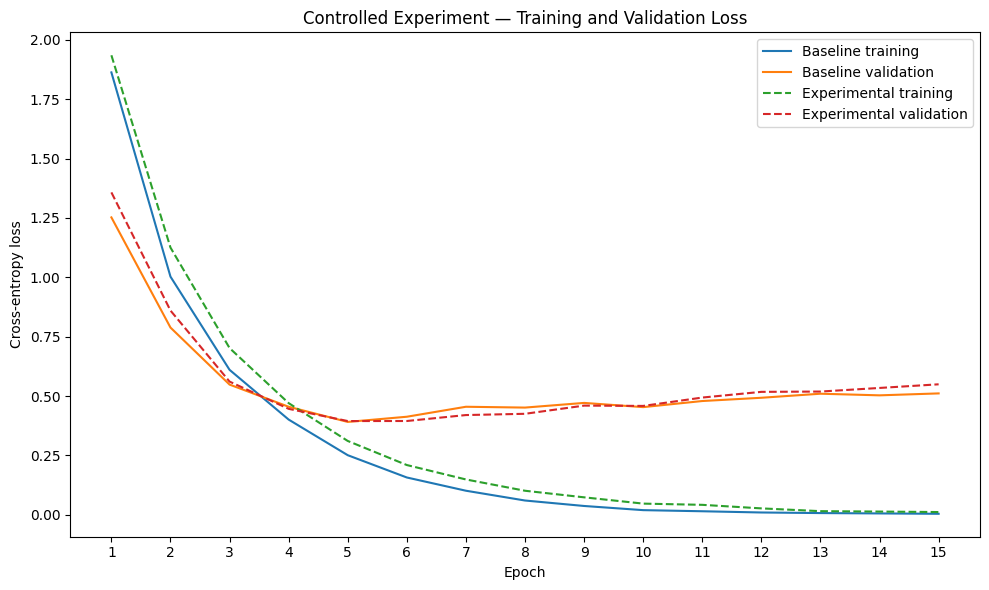

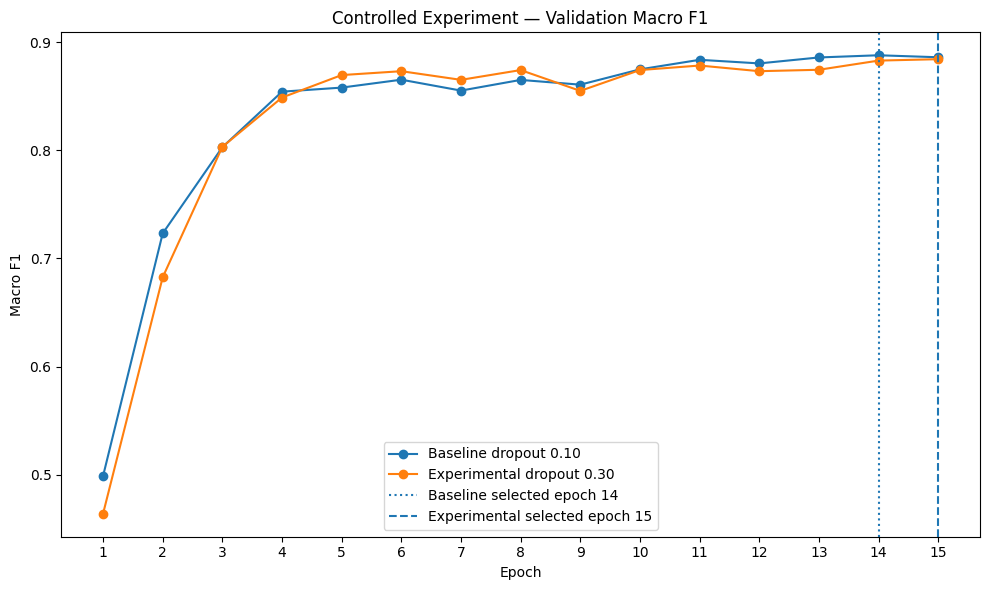

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(baseline_history["epoch"], baseline_history["train_loss"], label="Baseline training")
ax.plot(baseline_history["epoch"], baseline_history["validation_loss"], label="Baseline validation")
ax.plot(
    experimental_history["epoch"],
    experimental_history["train_loss"],
    linestyle="--",
    label="Experimental training",
)
ax.plot(
    experimental_history["epoch"],
    experimental_history["validation_loss"],
    linestyle="--",
    label="Experimental validation",
)
ax.set_title("Controlled Experiment — Training and Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_xticks(range(1, FORMAL_EPOCHS + 1))
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    baseline_history["epoch"],
    baseline_history["validation_macro_f1"],
    marker="o",
    label="Baseline dropout 0.10",
)
ax.plot(
    experimental_history["epoch"],
    experimental_history["validation_macro_f1"],
    marker="o",
    label="Experimental dropout 0.30",
)
ax.axvline(
    baseline_run_summary["best_epoch"],
    linestyle=":",
    label=f"Baseline selected epoch {baseline_run_summary['best_epoch']}",
)
ax.axvline(
    experimental_run_summary["best_epoch"],
    linestyle="--",
    label=f"Experimental selected epoch {experimental_run_summary['best_epoch']}",
)
ax.set_title("Controlled Experiment — Validation Macro F1")
ax.set_xlabel("Epoch")
ax.set_ylabel("Macro F1")
ax.set_xticks(range(1, FORMAL_EPOCHS + 1))
ax.legend()
plt.tight_layout()
plt.show()

## 31. Quantify generalization gaps at the selected epochs

The train-minus-validation macro-F1 gap is a simple diagnostic of fitting behavior. It is interpreted together with the loss curves and, later, final test performance.

In [31]:
def selected_epoch_row(history: pd.DataFrame, selected_epoch: int) -> pd.Series:
    matching = history.loc[history["epoch"] == selected_epoch]
    if len(matching) != 1:
        raise ValueError("Selected epoch must map to exactly one row.")
    return matching.iloc[0]

baseline_selected = selected_epoch_row(
    baseline_history, baseline_run_summary["best_epoch"]
)
experimental_selected = selected_epoch_row(
    experimental_history, experimental_run_summary["best_epoch"]
)

generalization_gap_table = pd.DataFrame(
    {
        "Configuration": [
            "Baseline dropout 0.10",
            "Experimental dropout 0.30",
        ],
        "Selected epoch": [
            baseline_run_summary["best_epoch"],
            experimental_run_summary["best_epoch"],
        ],
        "Training macro F1": [
            baseline_selected["train_macro_f1"],
            experimental_selected["train_macro_f1"],
        ],
        "Validation macro F1": [
            baseline_selected["validation_macro_f1"],
            experimental_selected["validation_macro_f1"],
        ],
        "Train minus validation F1": [
            baseline_selected["train_macro_f1"]
            - baseline_selected["validation_macro_f1"],
            experimental_selected["train_macro_f1"]
            - experimental_selected["validation_macro_f1"],
        ],
        "Training loss": [
            baseline_selected["train_loss"],
            experimental_selected["train_loss"],
        ],
        "Validation loss": [
            baseline_selected["validation_loss"],
            experimental_selected["validation_loss"],
        ],
    }
)

display(generalization_gap_table.style.format({
    "Training macro F1": "{:.4f}",
    "Validation macro F1": "{:.4f}",
    "Train minus validation F1": "{:+.4f}",
    "Training loss": "{:.4f}",
    "Validation loss": "{:.4f}",
}))

,Configuration,Selected epoch,Training macro F1,Validation macro F1,Train minus validation F1,Training loss,Validation loss
0,Baseline dropout 0.10,14,0.9988,0.8878,+0.1110,0.0056,0.5029
1,Experimental dropout 0.30,15,0.9981,0.8842,+0.1140,0.0114,0.5494


## 32. Preserve formal histories and confirm the test set remains untouched

Both complete histories and CPU checkpoint states remain in memory for final evaluation. No test loader is passed to `evaluate_model` in this phase.

In [32]:
formal_training_history = pd.concat(
    [
        baseline_history.assign(configuration="Baseline dropout 0.10"),
        experimental_history.assign(configuration="Experimental dropout 0.30"),
    ],
    ignore_index=True,
)

formal_training_summary = pd.DataFrame(
    [
        {
            "configuration": "Baseline dropout 0.10",
            "dropout": baseline_dropout,
            "best_epoch": baseline_run_summary["best_epoch"],
            "best_validation_loss": baseline_best_validation["loss"],
            "best_validation_accuracy": baseline_best_validation["accuracy"],
            "best_validation_macro_f1": baseline_best_validation["macro_f1"],
            "best_validation_weighted_f1": baseline_best_validation["weighted_f1"],
            "total_seconds": baseline_run_summary["total_seconds"],
            "peak_gpu_memory_gb": baseline_peak_memory_gb,
        },
        {
            "configuration": "Experimental dropout 0.30",
            "dropout": experimental_dropout,
            "best_epoch": experimental_run_summary["best_epoch"],
            "best_validation_loss": experimental_best_validation["loss"],
            "best_validation_accuracy": experimental_best_validation["accuracy"],
            "best_validation_macro_f1": experimental_best_validation["macro_f1"],
            "best_validation_weighted_f1": experimental_best_validation["weighted_f1"],
            "total_seconds": experimental_run_summary["total_seconds"],
            "peak_gpu_memory_gb": experimental_peak_memory_gb,
        },
    ]
)

assert len(baseline_history) == 15
assert len(experimental_history) == 15
assert baseline_checkpoint_matches
assert experimental_checkpoint_matches
assert len(baseline_best_state) == len(experimental_best_state)

display(formal_training_summary)
print(
    "Formal controlled training complete. Both best validation checkpoints "
    "are frozen, and the test partition has not been evaluated."
)

,configuration,dropout,best_epoch,best_validation_loss,best_validation_accuracy,best_validation_macro_f1,best_validation_weighted_f1,total_seconds,peak_gpu_memory_gb
0,Baseline dropout 0.10,0.1,14,0.502933,0.901149,0.887792,0.901110,36.633031,0.28428
1,Experimental dropout 0.30,0.3,15,0.549413,0.896552,0.884167,0.896722,40.981538,0.28428


Formal controlled training complete. Both best validation checkpoints are frozen, and the test partition has not been evaluated.


## Phase 9 checkpoint

The full controlled experiment is complete when:

- Identical initial parameters and shuffled batch order are verified.
- Dropout is the only major change.
- Both configurations run exactly 15 epochs.
- Complete training and validation histories are retained.
- Both best validation checkpoints restore correctly.
- Validation performance and generalization behavior are compared directly.
- Both checkpoint states remain available for final evaluation.
- The test partition remains untouched.

The next phase evaluates both frozen checkpoints on the same test split, computes aggregate and per-class metrics, creates confusion matrices, and identifies representative correct predictions, errors, high-confidence errors, and truncation-related cases.